In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the unemployment dataset

df = pd.read_csv('/content/Unemployment in India.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 7)


In [3]:
# Display the first 5 rows

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
# Display dataset information

print("Dataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB

Column Names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [5]:
# Check missing values

print("Missing values in each column:\n")
print(df.isnull().sum())

Missing values in each column:

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [6]:
# Display rows containing missing values

missing_rows = df[df.isnull().any(axis=1)]

print("Number of rows with missing values:", len(missing_rows))

missing_rows

Number of rows with missing values: 28


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Check how many values are present in each missing row

missing_rows.notnull().sum(axis=1).value_counts()

,count
0,28


In [8]:
# Remove completely empty rows

df = df.dropna(how='all').reset_index(drop=True)

print("Dataset shape after removing empty rows:", df.shape)
print("\nRemaining missing values:")
print(df.isnull().sum())

Dataset shape after removing empty rows: (740, 7)

Remaining missing values:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64


In [10]:
# Check the exact column names in the dataset

print("Original column names:")
for column in df.columns:
    print(repr(column))

Original column names:
'Region'
' Date'
' Frequency'
' Estimated Unemployment Rate (%)'
' Estimated Employed'
' Estimated Labour Participation Rate (%)'
'Area'


In [11]:
# Clean all column names by removing leading/trailing spaces

df.columns = df.columns.str.strip()

print("Cleaned column names:")
for column in df.columns:
    print(repr(column))

Cleaned column names:
'Region'
'Date'
'Frequency'
'Estimated Unemployment Rate (%)'
'Estimated Employed'
'Estimated Labour Participation Rate (%)'
'Area'


In [12]:
# Clean unnecessary spaces from text values

text_columns = ['Region', 'Frequency', 'Area']

for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

print("Text columns cleaned successfully!")

Text columns cleaned successfully!


In [13]:
# Convert Date column to datetime format

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Date conversion completed!")

print("\nDate range:")
print("Start:", df['Date'].min())
print("End:", df['Date'].max())

Date conversion completed!

Date range:
Start: 2019-05-31 00:00:00
End: 2020-06-30 00:00:00


In [14]:
# Final data quality check

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (740, 7)

Data Types:
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

First 5 rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [16]:
# Statistical summary of numerical variables

df.describe()
# Check regions and area categories

print("Number of unique regions:", df['Region'].nunique())

print("\nRegions:")
print(df['Region'].unique())

print("\nArea categories:")
print(df['Area'].unique())

print("\nFrequency:")
print(df['Frequency'].unique())

Number of unique regions: 28

Regions:
['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']

Area categories:
['Rural' 'Urban']

Frequency:
['Monthly']


In [17]:
# Compare average unemployment rate between Rural and Urban areas

area_unemployment = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate by Area:")
print(area_unemployment)

Average Unemployment Rate by Area:
Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


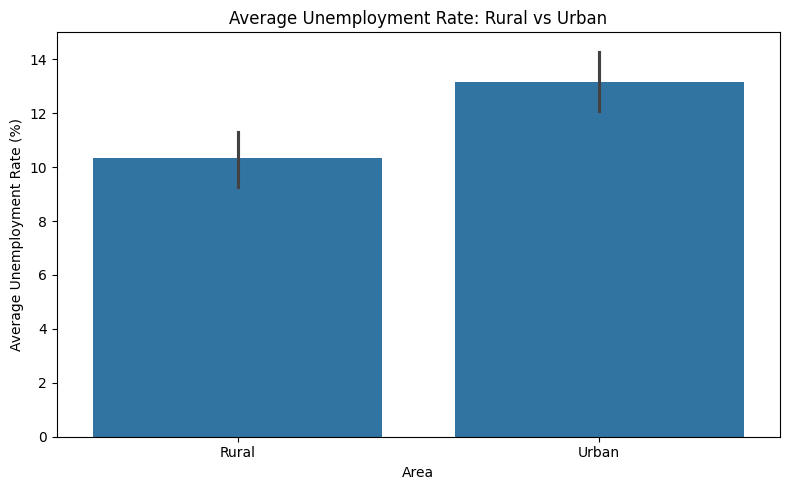

In [18]:
# Visualize average unemployment rate by area

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')

plt.tight_layout()
plt.show()

In [19]:
# Calculate average unemployment rate for each month

monthly_unemployment = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

monthly_unemployment.head()

,Date,Estimated Unemployment Rate (%)
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731


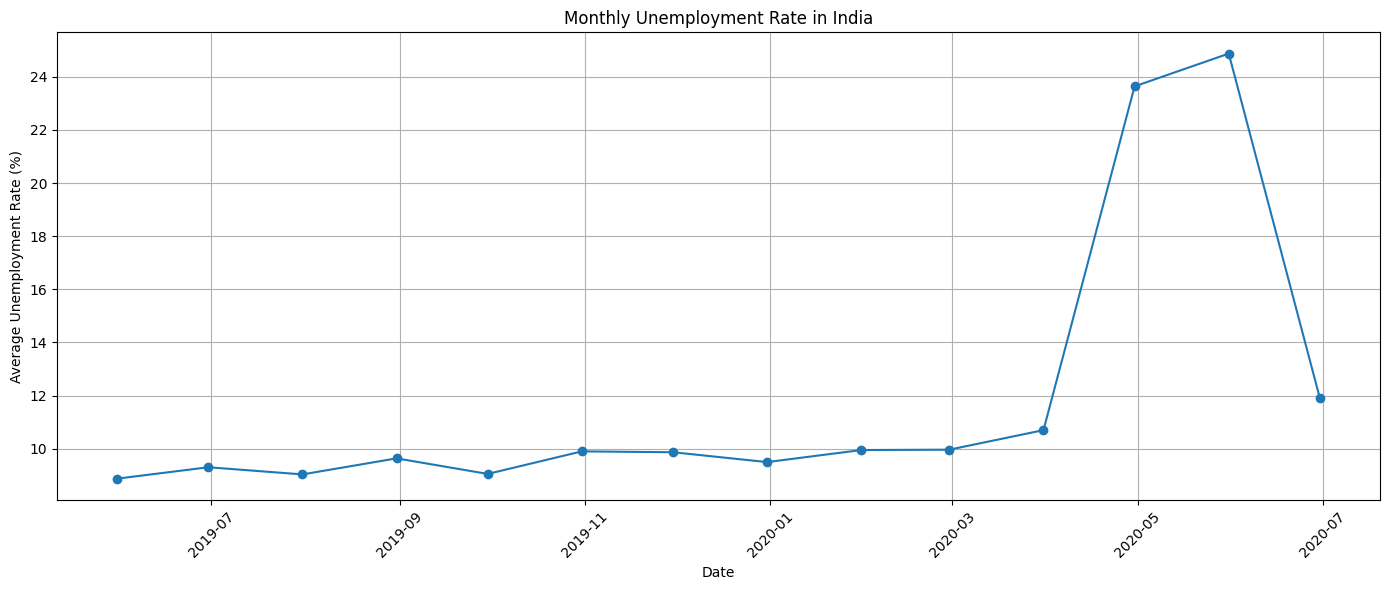

In [20]:
# Plot monthly unemployment trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment['Date'],
    monthly_unemployment['Estimated Unemployment Rate (%)'],
    marker='o'
)

plt.title('Monthly Unemployment Rate in India')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Analyze unemployment before, during, and after the major COVID-19 increase

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

yearly_unemployment = (
    df.groupby('Year')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

print("Average Unemployment Rate by Year:\n")
print(yearly_unemployment)

Average Unemployment Rate by Year:

   Year  Estimated Unemployment Rate (%)
0  2019                         9.399047
1  2020                        15.101581


In [22]:
# Calculate monthly unemployment rates for the COVID-19 period

covid_period = (
    df[(df['Date'] >= '2020-01-01') & (df['Date'] <= '2020-12-31')]
    .groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

print("COVID-19 Period Monthly Unemployment:\n")
print(covid_period)

COVID-19 Period Monthly Unemployment:

        Date  Estimated Unemployment Rate (%)
0 2020-01-31                         9.950755
1 2020-02-29                         9.964717
2 2020-03-31                        10.700577
3 2020-04-30                        23.641569
4 2020-05-31                        24.875294
5 2020-06-30                        11.903600


In [23]:
# Find the month with the highest average unemployment rate

highest_month = monthly_unemployment.loc[
    monthly_unemployment['Estimated Unemployment Rate (%)'].idxmax()
]

print("Month with Highest Unemployment:")
print("Date:", highest_month['Date'].strftime('%B %Y'))
print(
    "Average Unemployment Rate:",
    f"{highest_month['Estimated Unemployment Rate (%)']:.2f}%"
)

Month with Highest Unemployment:
Date: May 2020
Average Unemployment Rate: 24.88%


"The unemployment rate was relatively stable during 2019 and early 2020, followed by a sharp increase during the COVID-19 period. The highest monthly unemployment rate in the analyzed dataset occurred in [exact month], reaching [exact percentage]."

In [24]:
# Calculate average unemployment rate by region

state_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

print("Average Unemployment Rate by Region:\n")
print(state_unemployment)

Average Unemployment Rate by Region:

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


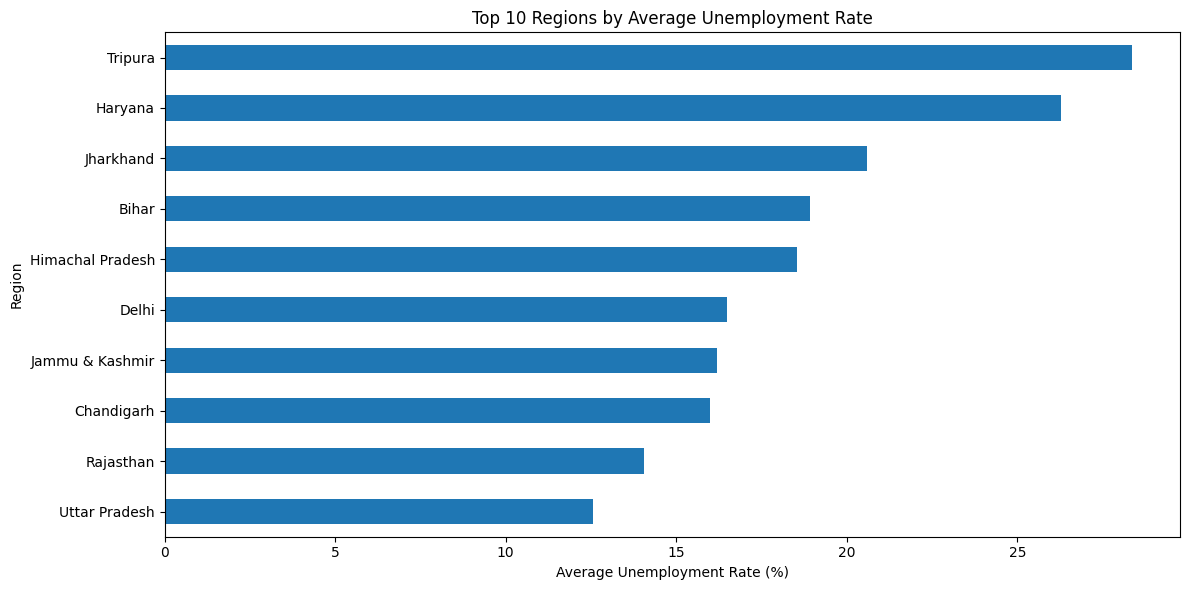

In [25]:
# Top 10 regions with highest average unemployment rate

top_10_regions = state_unemployment.head(10)

plt.figure(figsize=(12, 6))

top_10_regions.sort_values().plot(kind='barh')

plt.title('Top 10 Regions by Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

In [26]:
# Bottom 10 regions with lowest average unemployment rate

bottom_10_regions = state_unemployment.tail(10).sort_values()

print("10 Regions with Lowest Average Unemployment Rate:\n")
print(bottom_10_regions)

10 Regions with Lowest Average Unemployment Rate:

Region
Meghalaya         4.798889
Odisha            5.657857
Assam             6.428077
Uttarakhand       6.582963
Gujarat           6.663929
Karnataka         6.676071
Sikkim            7.249412
Madhya Pradesh    7.406429
Andhra Pradesh    7.477143
Maharashtra       7.557500
Name: Estimated Unemployment Rate (%), dtype: float64


In [27]:
# Top 10 regions with highest average unemployment rate

top_10_regions = state_unemployment.head(10)

print("10 Regions with Highest Average Unemployment Rate:\n")
print(top_10_regions)

10 Regions with Highest Average Unemployment Rate:

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


In [28]:
# Compare unemployment before COVID and during the major COVID spike

pre_covid = (
    df[df['Year'] == 2019]
    .groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
)

covid_peak = (
    df[
        (df['Date'] >= '2020-04-01') &
        (df['Date'] <= '2020-05-31')
    ]
    .groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
)

covid_comparison = pd.DataFrame({
    '2019 Average': pre_covid,
    'Apr-May 2020 Average': covid_peak
})

covid_comparison['Increase (%)'] = (
    covid_comparison['Apr-May 2020 Average']
    - covid_comparison['2019 Average']
)

covid_comparison = covid_comparison.sort_values(
    'Increase (%)',
    ascending=False
)

covid_comparison.head(10)

,2019 Average,Apr-May 2020 Average,Increase (%)
Region,,,
Puducherry,1.699375,75.416667,73.717292
Jharkhand,14.233750,57.117500,42.883750
Tamil Nadu,3.063750,40.855000,37.791250
Bihar,13.882500,47.247500,33.365000
Karnataka,3.238750,24.472500,21.233750
Haryana,22.798750,40.295000,17.496250
Telangana,4.115625,21.397500,17.281875
Andhra Pradesh,4.826875,21.990000,17.163125
Madhya Pradesh,4.788125,21.847500,17.059375


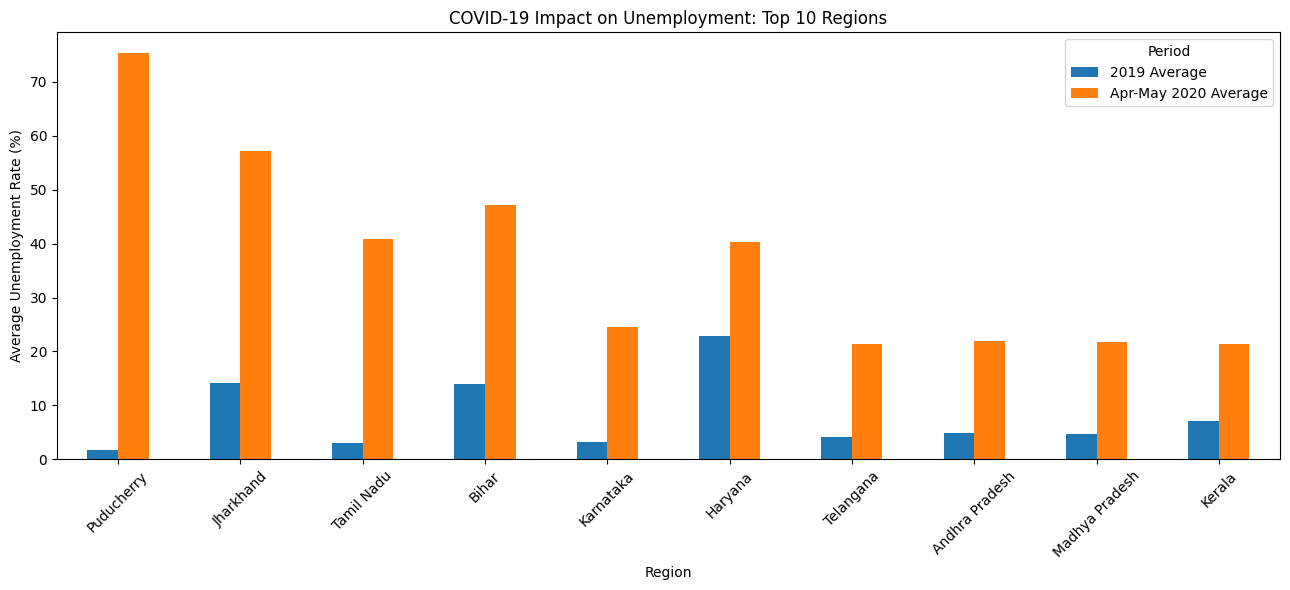

In [29]:
# Visualize the top 10 regions with the largest COVID-related increase

top_covid_impact = covid_comparison.head(10)

top_covid_impact[['2019 Average', 'Apr-May 2020 Average']].plot(
    kind='bar',
    figsize=(13, 6)
)

plt.title('COVID-19 Impact on Unemployment: Top 10 Regions')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.legend(title='Period')

plt.tight_layout()
plt.show()

In [30]:
# Select numerical columns for correlation analysis

numerical_columns = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

correlation_matrix = df[numerical_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


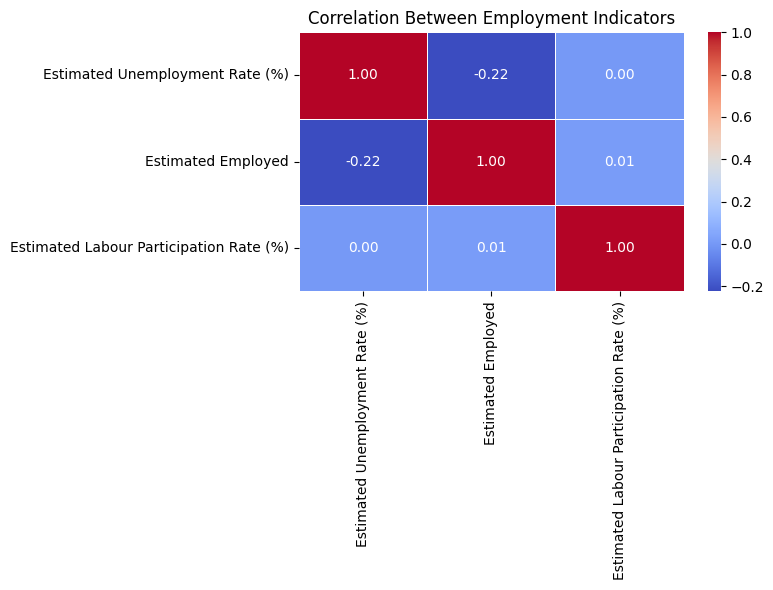

In [31]:
# Visualize correlations between numerical variables

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Between Employment Indicators')

plt.tight_layout()
plt.show()

We'll look at the relationship between:

Unemployment Rate ↔ Estimated Employed

Unemployment Rate ↔ Labour Participation Rate

Estimated Employed ↔ Labour Participation Rate

The correlation values will help us describe whether these variables have positive, negative, or weak relationships in this dataset.

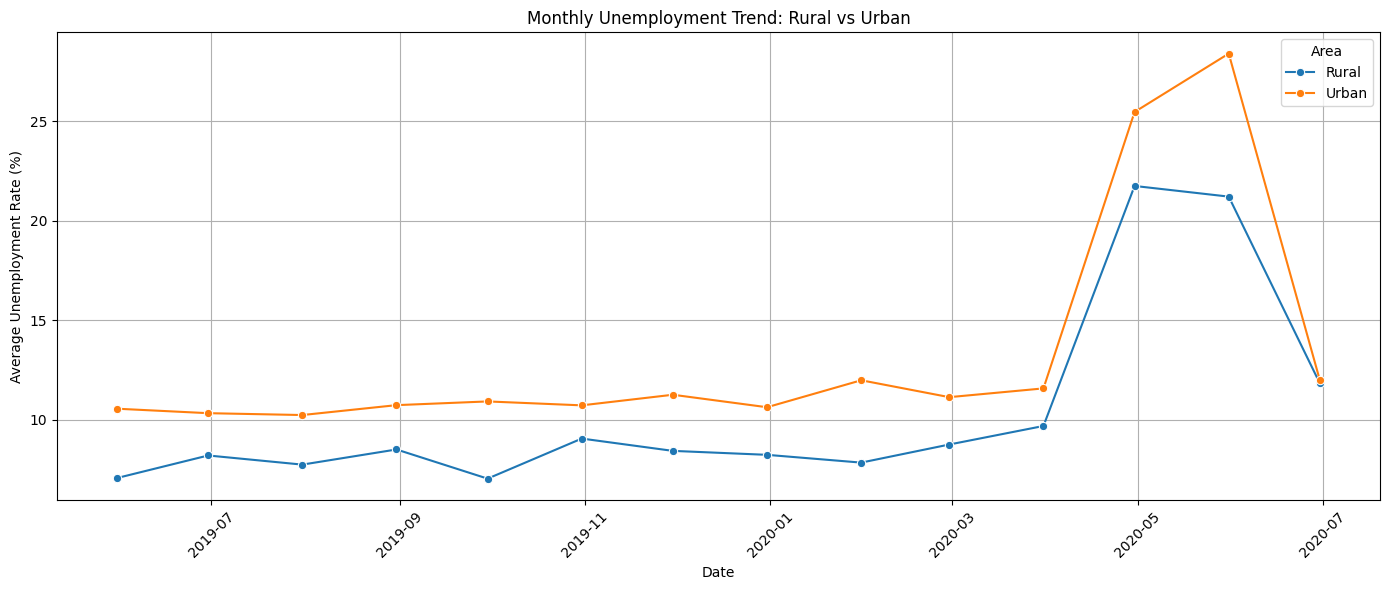

In [32]:
# Calculate monthly unemployment by area

monthly_area = (
    df.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_area,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Area',
    marker='o'
)

plt.title('Monthly Unemployment Trend: Rural vs Urban')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

"Urban areas generally recorded higher unemployment rates than rural areas. During the COVID-19 period, both experienced a sharp increase, with the urban unemployment rate showing a particularly strong spike."

In [33]:
# Display the correlation matrix

correlation_matrix = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].corr()

display(correlation_matrix)

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


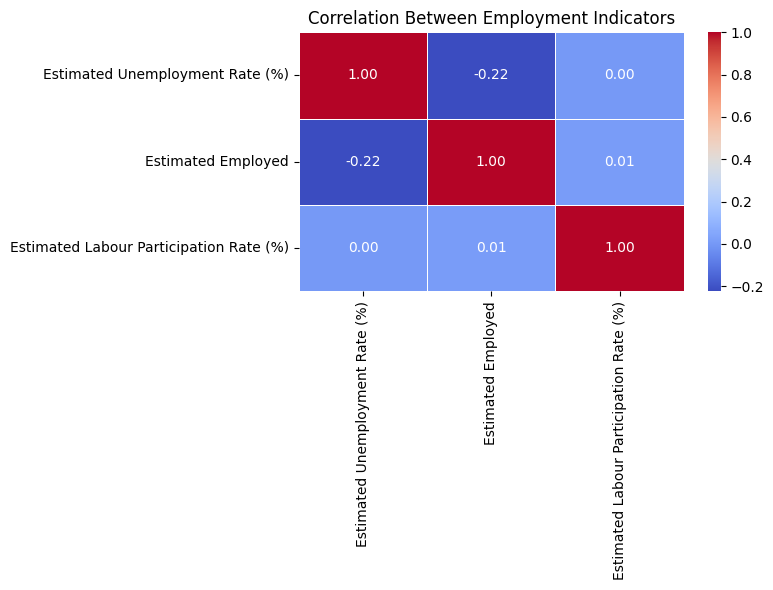

In [34]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Between Employment Indicators')

plt.tight_layout()
plt.show()

In [35]:
# Detailed Rural vs Urban statistics

area_statistics = df.groupby('Area')[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].mean()

print("Average Employment Indicators by Area:")
display(area_statistics)

Average Employment Indicators by Area:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Area,,,
Rural,10.324791,1.019285e+07,44.464819
Urban,13.166614,4.388626e+06,40.901365


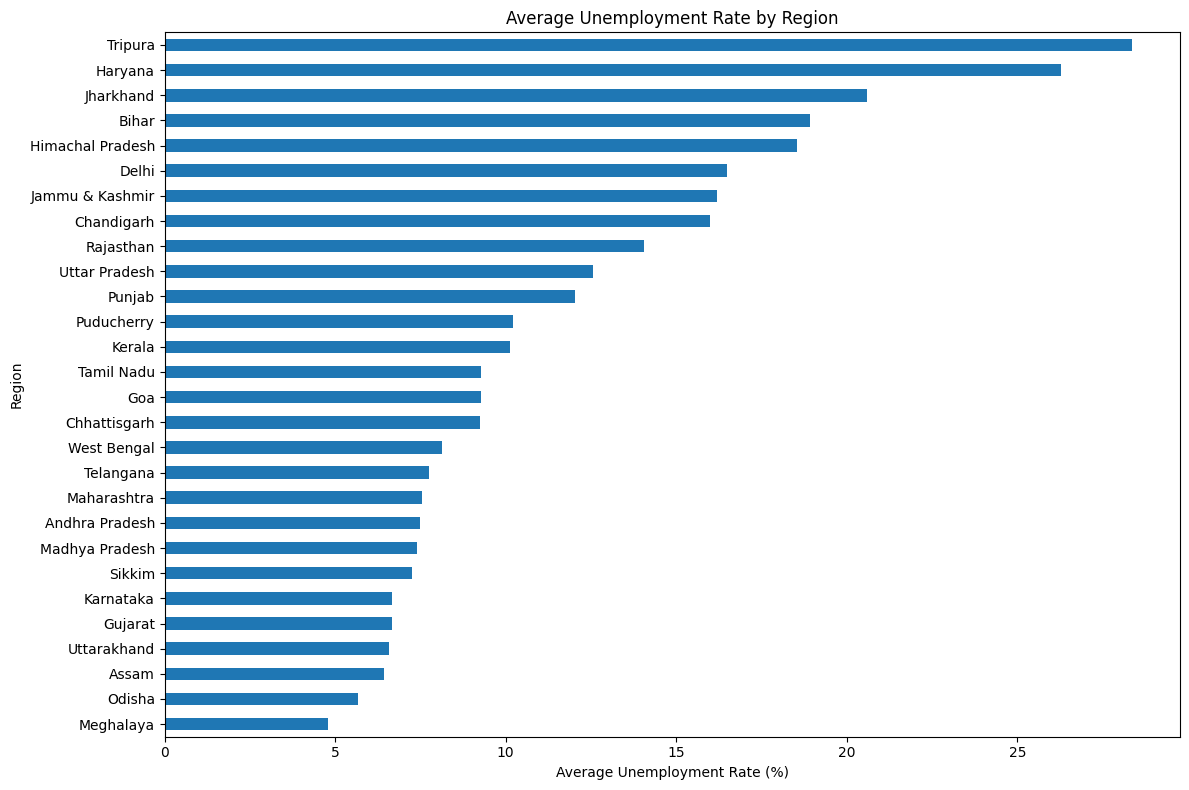

In [36]:
# Average unemployment rate by region

plt.figure(figsize=(12, 8))

state_unemployment.sort_values().plot(kind='barh')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

In [37]:
# Generate final key statistics

highest_region = state_unemployment.idxmax()
highest_region_rate = state_unemployment.max()

lowest_region = state_unemployment.idxmin()
lowest_region_rate = state_unemployment.min()

highest_month_rate = highest_month['Estimated Unemployment Rate (%)']
highest_month_date = highest_month['Date']

print("========== FINAL KEY STATISTICS ==========")

print(f"Total valid records: {len(df)}")
print(f"Number of regions: {df['Region'].nunique()}")

print(
    f"\nHighest regional average unemployment: "
    f"{highest_region} ({highest_region_rate:.2f}%)"
)

print(
    f"Lowest regional average unemployment: "
    f"{lowest_region} ({lowest_region_rate:.2f}%)"
)

print(
    f"\nHighest monthly unemployment: "
    f"{highest_month_date.strftime('%B %Y')} "
    f"({highest_month_rate:.2f}%)"
)

print(
    f"\nRural average unemployment: "
    f"{area_statistics.loc['Rural', 'Estimated Unemployment Rate (%)']:.2f}%"
)

print(
    f"Urban average unemployment: "
    f"{area_statistics.loc['Urban', 'Estimated Unemployment Rate (%)']:.2f}%"
)

print("==========================================")

========== FINAL KEY STATISTICS ==========
Total valid records: 740
Number of regions: 28

Highest regional average unemployment: Tripura (28.35%)
Lowest regional average unemployment: Meghalaya (4.80%)

Highest monthly unemployment: May 2020 (24.88%)

Rural average unemployment: 10.32%
Urban average unemployment: 13.17%


# 📌 Key Findings

The analysis of unemployment data produced the following major findings:

1. The cleaned dataset contains **740 valid records** covering **28 regions** in India.

2. The unemployment rate remained relatively stable during most of 2019 and early 2020.

3. A major increase in unemployment was observed during the COVID-19 period.

4. The highest monthly average unemployment rate was recorded in **May 2020 at 24.88%**.

5. The unemployment rate increased sharply during April and May 2020 compared with the 2019 period.

6. **Tripura** recorded the highest average regional unemployment rate at **28.35%** in the analyzed dataset.

7. **Meghalaya** recorded the lowest average regional unemployment rate at **4.80%**.

8. Urban areas had a higher average unemployment rate (**13.17%**) than rural areas (**10.32%**).

9. Both rural and urban areas experienced a substantial unemployment spike during the COVID-19 period.

10. The correlation analysis showed an approximately zero linear correlation between unemployment rate and labour participation rate in this dataset.

# 🦠 COVID-19 Impact Analysis

The time-series analysis shows a clear disruption in unemployment during the COVID-19 period.

During January to March 2020, the average unemployment rate remained close to 10%. However, unemployment increased sharply during the lockdown period.

The average unemployment rate increased to:

- **April 2020:** 23.64%
- **May 2020:** 24.88%
- **June 2020:** 11.90%

The highest monthly unemployment rate in the dataset was **24.88% in May 2020**.

The regional comparison also showed substantial increases in unemployment during April–May 2020 compared with the 2019 average.

This indicates a strong short-term employment shock during the COVID-19 period represented in the dataset.

# 📝 Conclusion

This project analyzed unemployment trends in India using a dataset containing monthly unemployment observations across different regions and areas.

The analysis included data cleaning, exploratory data analysis, statistical analysis, regional comparisons, rural-versus-urban analysis, time-series visualization, COVID-19 impact analysis, and correlation analysis.

The results show that unemployment experienced a major increase during the COVID-19 period, with the highest monthly average of **24.88% recorded in May 2020**.

Regional unemployment also varied considerably. Tripura had the highest average regional unemployment rate at **28.35%**, while Meghalaya had the lowest at **4.80%**.

The analysis also found that the average unemployment rate was higher in urban areas (**13.17%**) than rural areas (**10.32%**).

Overall, the project demonstrates how data analysis and visualization can be used to identify unemployment trends, regional differences, and major changes during significant economic events.

# 📊 Unemployment Analysis in India

## CodeAlpha Data Science Internship — Task 2

### Project Overview

This project analyzes unemployment trends across different regions and areas of India using Python and data visualization techniques.

The analysis focuses on:

- Overall unemployment trends
- Regional differences
- Rural vs Urban unemployment
- COVID-19 impact on unemployment
- Employment indicators
- Correlation between variables

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab